# MinHash Algorithm

## Learning Objectives

By the end of this notebook you will be able to:

1. **Explain** why Jaccard similarity is the right measure for set similarity
2. **Define** the MinHash function and its connection to random permutations
3. **Prove** the key theorem: P[h(A) = h(B)] = Jaccard(A, B)
4. **Derive** the signature matrix construction using k hash functions
5. **Implement** MinHash from scratch using linear hash functions
6. **Analyse** the error bound: standard deviation ≈ 1/√k


## Problem Statement

### Motivation

Given millions of documents (web pages, news articles, code files), find all pairs that are *nearly identical* — e.g. plagiarised copies, duplicate news stories, near-duplicate product descriptions.

**Naïve approach:** compare every pair of documents. For $n$ documents this is $O(n^2)$ comparisons — infeasible for $n = 10^9$.

**Key observation:** representing each document as a *set of shingles* (k-grams), two documents are similar if and only if their shingle sets have high Jaccard similarity.

### Jaccard Similarity

For two sets $A$ and $B$:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

| Value | Interpretation |
|-------|---------------|
| 0 | completely disjoint |
| 1 | identical sets |
| 0.8 | very similar (near-duplicate) |
| 0.3 | somewhat related |

**Problem:** computing exact Jaccard for all pairs still takes $O(n^2 |S|)$ time where $|S|$ is the set size.

### The MinHash Solution

*Compress* each set into a short signature of $k$ integers such that:

$$P[\text{sig}(A)[i] = \text{sig}(B)[i]] = J(A, B)$$

Then estimate Jaccard from the fraction of signature positions that agree — in $O(k)$ time per pair, with $k \ll |S|$.


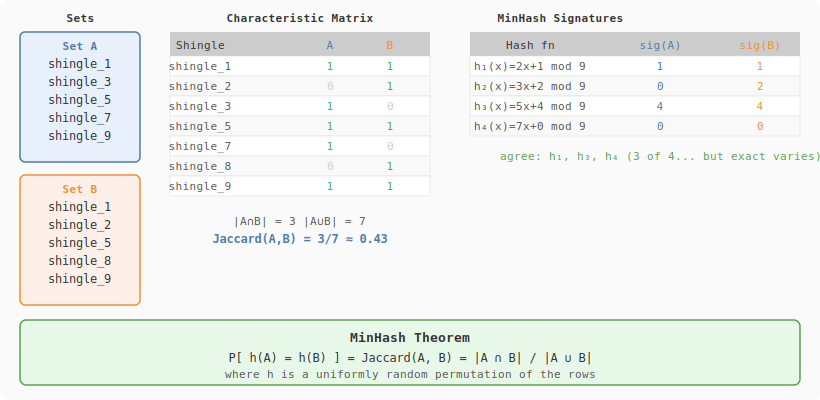

In [1]:
from IPython.display import SVG, display

svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="400" font-family="monospace" font-size="12">

  <!-- background -->
  <rect width="820" height="400" fill="#fafafa" rx="8"/>

  <!-- ── arrowhead marker ── -->
  <defs>
    <marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto">
      <polygon points="0 0, 8 3, 0 6" fill="#999"/>
    </marker>
  </defs>

  <!-- ═══ STEP 1: Sets ═══ -->
  <text x="80" y="22" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">Sets</text>

  <!-- Set A -->
  <rect x="20" y="32" width="120" height="130" rx="5" fill="#e8f0fb" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="80" y="50" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">Set A</text>
  <text x="80" y="68"  text-anchor="middle" fill="#333">shingle_1</text>
  <text x="80" y="86"  text-anchor="middle" fill="#333">shingle_3</text>
  <text x="80" y="104" text-anchor="middle" fill="#333">shingle_5</text>
  <text x="80" y="122" text-anchor="middle" fill="#333">shingle_7</text>
  <text x="80" y="140" text-anchor="middle" fill="#333">shingle_9</text>

  <!-- Set B -->
  <rect x="20" y="175" width="120" height="130" rx="5" fill="#fef0e8" stroke="#f28e2b" stroke-width="1.5"/>
  <text x="80" y="193" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Set B</text>
  <text x="80" y="211" text-anchor="middle" fill="#333">shingle_1</text>
  <text x="80" y="229" text-anchor="middle" fill="#333">shingle_2</text>
  <text x="80" y="247" text-anchor="middle" fill="#333">shingle_5</text>
  <text x="80" y="265" text-anchor="middle" fill="#333">shingle_8</text>
  <text x="80" y="283" text-anchor="middle" fill="#333">shingle_9</text>

  <!-- ═══ STEP 2: Characteristic matrix ═══ -->
  <text x="300" y="22" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">Characteristic Matrix</text>

  <!-- header row -->
  <rect x="170" y="32" width="260" height="24" rx="0" fill="#ccc"/>
  <text x="200" y="49" text-anchor="middle" fill="#333" font-size="11">Shingle</text>
  <text x="330" y="49" text-anchor="middle" fill="#4e79a7" font-size="11">A</text>
  <text x="390" y="49" text-anchor="middle" fill="#f28e2b" font-size="11">B</text>

  <!-- rows -->
  <rect x="170" y="56" width="260" height="20" fill="#fff" stroke="#ddd" stroke-width="0.5"/>
  <text x="200" y="70" text-anchor="middle" fill="#555" font-size="11">shingle_1</text>
  <text x="330" y="70" text-anchor="middle" fill="#59a14f" font-size="11">1</text>
  <text x="390" y="70" text-anchor="middle" fill="#59a14f" font-size="11">1</text>

  <rect x="170" y="76" width="260" height="20" fill="#f9f9f9" stroke="#ddd" stroke-width="0.5"/>
  <text x="200" y="90" text-anchor="middle" fill="#555" font-size="11">shingle_2</text>
  <text x="330" y="90" text-anchor="middle" fill="#ccc" font-size="11">0</text>
  <text x="390" y="90" text-anchor="middle" fill="#59a14f" font-size="11">1</text>

  <rect x="170" y="96" width="260" height="20" fill="#fff" stroke="#ddd" stroke-width="0.5"/>
  <text x="200" y="110" text-anchor="middle" fill="#555" font-size="11">shingle_3</text>
  <text x="330" y="110" text-anchor="middle" fill="#59a14f" font-size="11">1</text>
  <text x="390" y="110" text-anchor="middle" fill="#ccc" font-size="11">0</text>

  <rect x="170" y="116" width="260" height="20" fill="#f9f9f9" stroke="#ddd" stroke-width="0.5"/>
  <text x="200" y="130" text-anchor="middle" fill="#555" font-size="11">shingle_5</text>
  <text x="330" y="130" text-anchor="middle" fill="#59a14f" font-size="11">1</text>
  <text x="390" y="130" text-anchor="middle" fill="#59a14f" font-size="11">1</text>

  <rect x="170" y="136" width="260" height="20" fill="#fff" stroke="#ddd" stroke-width="0.5"/>
  <text x="200" y="150" text-anchor="middle" fill="#555" font-size="11">shingle_7</text>
  <text x="330" y="150" text-anchor="middle" fill="#59a14f" font-size="11">1</text>
  <text x="390" y="150" text-anchor="middle" fill="#ccc" font-size="11">0</text>

  <rect x="170" y="156" width="260" height="20" fill="#f9f9f9" stroke="#ddd" stroke-width="0.5"/>
  <text x="200" y="170" text-anchor="middle" fill="#555" font-size="11">shingle_8</text>
  <text x="330" y="170" text-anchor="middle" fill="#ccc" font-size="11">0</text>
  <text x="390" y="170" text-anchor="middle" fill="#59a14f" font-size="11">1</text>

  <rect x="170" y="176" width="260" height="20" fill="#fff" stroke="#ddd" stroke-width="0.5"/>
  <text x="200" y="190" text-anchor="middle" fill="#555" font-size="11">shingle_9</text>
  <text x="330" y="190" text-anchor="middle" fill="#59a14f" font-size="11">1</text>
  <text x="390" y="190" text-anchor="middle" fill="#59a14f" font-size="11">1</text>

  <!-- Jaccard -->
  <text x="300" y="225" text-anchor="middle" fill="#555" font-size="11">|A∩B| = 3  |A∪B| = 7</text>
  <text x="300" y="243" text-anchor="middle" fill="#4e79a7" font-size="12" font-weight="bold">Jaccard(A,B) = 3/7 ≈ 0.43</text>

  <!-- ═══ STEP 3: Hash functions ═══ -->
  <text x="560" y="22" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">MinHash Signatures</text>

  <!-- signature matrix header -->
  <rect x="470" y="32" width="330" height="24" rx="0" fill="#ccc"/>
  <text x="530" y="49" text-anchor="middle" fill="#333" font-size="11">Hash fn</text>
  <text x="660" y="49" text-anchor="middle" fill="#4e79a7" font-size="11">sig(A)</text>
  <text x="760" y="49" text-anchor="middle" fill="#f28e2b" font-size="11">sig(B)</text>

  <!-- rows for each hash function -->
  <rect x="470" y="56"  width="330" height="20" fill="#fff" stroke="#ddd" stroke-width="0.5"/>
  <text x="530" y="70"  text-anchor="middle" fill="#555" font-size="11">h₁(x)=2x+1 mod 9</text>
  <text x="660" y="70"  text-anchor="middle" fill="#4e79a7" font-size="11">1</text>
  <text x="760" y="70"  text-anchor="middle" fill="#f28e2b" font-size="11">1</text>

  <rect x="470" y="76"  width="330" height="20" fill="#f9f9f9" stroke="#ddd" stroke-width="0.5"/>
  <text x="530" y="90"  text-anchor="middle" fill="#555" font-size="11">h₂(x)=3x+2 mod 9</text>
  <text x="660" y="90"  text-anchor="middle" fill="#4e79a7" font-size="11">0</text>
  <text x="760" y="90"  text-anchor="middle" fill="#f28e2b" font-size="11">2</text>

  <rect x="470" y="96"  width="330" height="20" fill="#fff" stroke="#ddd" stroke-width="0.5"/>
  <text x="530" y="110" text-anchor="middle" fill="#555" font-size="11">h₃(x)=5x+4 mod 9</text>
  <text x="660" y="110" text-anchor="middle" fill="#4e79a7" font-size="11">4</text>
  <text x="760" y="110" text-anchor="middle" fill="#f28e2b" font-size="11">4</text>

  <rect x="470" y="116" width="330" height="20" fill="#f9f9f9" stroke="#ddd" stroke-width="0.5"/>
  <text x="530" y="130" text-anchor="middle" fill="#555" font-size="11">h₄(x)=7x+0 mod 9</text>
  <text x="660" y="130" text-anchor="middle" fill="#4e79a7" font-size="11">0</text>
  <text x="760" y="130" text-anchor="middle" fill="#f28e2b" font-size="11">0</text>

  <!-- agreement annotation -->
  <text x="660" y="160" text-anchor="middle" fill="#59a14f" font-size="11">agree: h₁, h₃, h₄ (3 of 4... but exact varies)</text>

  <!-- ═══ KEY THEOREM ═══ -->
  <rect x="20" y="320" width="780" height="65" rx="6" fill="#e8f8e8" stroke="#59a14f" stroke-width="1.5"/>
  <text x="410" y="342" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">MinHash Theorem</text>
  <text x="410" y="362" text-anchor="middle" fill="#333" font-size="12">P[ h(A) = h(B) ]  =  Jaccard(A, B)  =  |A ∩ B| / |A ∪ B|</text>
  <text x="410" y="378" text-anchor="middle" fill="#555" font-size="11">where h is a uniformly random permutation of the rows</text>

</svg>
'''

display(SVG(svg))


## The Characteristic Matrix

**Definition:** Let $U = \{e_1, e_2, \ldots, e_m\}$ be the universe of all elements (all k-shingles across the corpus). The *characteristic matrix* $M$ is a binary matrix with:

- Rows = elements of $U$
- Columns = sets (documents)
- $M[e, C] = 1$ iff $e \in C$

### Jaccard from the Characteristic Matrix

Consider any row of $M$ and two columns $A$, $B$. The row falls into one of three types:

| Type | $M[e,A]$ | $M[e,B]$ | Counts as |
|------|----------|----------|-----------|
| **a** (both) | 1 | 1 | $\|A \cap B\|$ |
| **b** (A only) | 1 | 0 | $\|A \setminus B\|$ |
| **c** (B only) | 0 | 1 | $\|B \setminus A\|$ |
| **d** (neither) | 0 | 0 | — |

$$J(A, B) = \frac{a}{a + b + c}$$

Row type **d** (both zero) is irrelevant — sparse sets mean most rows are type **d**, which is why MinHash is efficient.


## The MinHash Function

### Definition

A *MinHash function* $h_\pi$ is defined by a uniformly random permutation $\pi$ of the rows:

$$h_\pi(C) = \min_{e \in C}\; \pi(e)$$

The MinHash of set $C$ under permutation $\pi$ is the *index of the first row (in the permuted order) where column $C$ has a 1*.

### The Key Theorem

$$\boxed{P_{\pi}\bigl[h_\pi(A) = h_\pi(B)\bigr] = J(A, B)}$$

**Proof:**

The first row in the permuted order where *at least one* of $A$, $B$ has a 1 is equally likely to be any of the $a + b + c$ rows of type a, b, or c.

- $h_\pi(A) = h_\pi(B)$ iff the first such row is type **a** (both columns are 1)
- The probability of landing on a type-a row is $\frac{a}{a+b+c} = J(A,B)$ $\square$

### Building a Signature

Apply $k$ independent random permutations $\pi_1, \ldots, \pi_k$:

$$\text{sig}(C) = \bigl[h_{\pi_1}(C),\; h_{\pi_2}(C),\; \ldots,\; h_{\pi_k}(C)\bigr] \in \mathbb{Z}^k$$

**Estimate Jaccard** from two signatures:

$$\hat{J}(A, B) = \frac{1}{k}\sum_{i=1}^{k} \mathbf{1}\bigl[\text{sig}(A)[i] = \text{sig}(B)[i]\bigr]$$

This is an unbiased estimator of $J(A, B)$.


## Derivation of the Algorithm

### Why Random Permutations Are Impractical

Storing and applying a random permutation of $m$ rows costs $O(m)$ space and time — and the universe $m$ can be in the billions (all possible k-shingles).

### The Linear Hash Trick

Approximate a random permutation with a linear hash function:

$$h_{a,b}(x) = (ax + b \bmod p) \bmod m$$

where:
- $p$ is a prime larger than $m$
- $a \in \{1, \ldots, p-1\}$, $b \in \{0, \ldots, p-1\}$ are chosen uniformly at random
- This maps row indices to $\{0, \ldots, m-1\}$ with near-uniform distribution

### Algorithm Steps

1. Choose $k$ random pairs $(a_i, b_i)$, defining $k$ hash functions $h_1, \ldots, h_k$
2. Initialise $\text{sig}[i][C] = +\infty$ for all $i$ and all sets $C$
3. For each element $e$ in the universe:
   - Compute $h_i(e)$ for each $i$
   - For each set $C$ where $e \in C$: update $\text{sig}[i][C] = \min(\text{sig}[i][C],\; h_i(e))$
4. Return the signature matrix $\text{sig}$ of shape $(k, |\text{sets}|)$

### Complexity

| Phase | Time | Space |
|-------|------|-------|
| Signature construction | $O(k \cdot \sum_C |C|)$ | $O(k \cdot n)$ |
| Pairwise Jaccard estimate | $O(k)$ per pair | — |
| Naïve pairwise exact | $O(|S|)$ per pair | — |

For $k = 200$ and $|S| = 10^5$, MinHash is **500× faster** per pair.

### Error Analysis

By the Central Limit Theorem, $\hat{J}$ is a sum of $k$ i.i.d. Bernoulli($J$) random variables:

$$\text{Var}(\hat{J}) = \frac{J(1-J)}{k} \leq \frac{1}{4k}$$

$$\text{std}(\hat{J}) \leq \frac{1}{2\sqrt{k}}$$

For $k = 100$: std ≤ 0.05.  For $k = 400$: std ≤ 0.025.


## Algorithm Steps

### Inputs

- $n$ sets $C_1, \ldots, C_n$ over a universe $U$ of size $m$
- Number of hash functions $k$

### Steps

1. **Initialise** signature matrix $\text{sig} \in \mathbb{Z}^{k \times n}$, all entries $= +\infty$

2. **Sample** $k$ hash functions: for $i = 1, \ldots, k$ draw $a_i, b_i$ and define $h_i(x) = (a_i x + b_i \bmod p) \bmod m$

3. **For each element** $e \in U$:
   - **For each hash function** $i$: compute $v = h_i(e)$
   - **For each set** $C_j$ with $e \in C_j$: set $\text{sig}[i][j] = \min(\text{sig}[i][j],\; v)$

4. **Output** signature matrix $\text{sig}$

### Estimate Similarity

For sets $C_a$ and $C_b$:

$$\hat{J}(C_a, C_b) = \frac{|\{i : \text{sig}[i][a] = \text{sig}[i][b]\}|}{k}$$


In [2]:
import numpy as np
from collections import defaultdict


def minhash_signatures(sets, n_hashes, universe_size=None):
    """
    Compute MinHash signature matrix for a collection of sets.

    Inputs
    ------
    sets         : list of set — each set contains integer element IDs
    n_hashes     : int — number of hash functions (= signature length k)
    universe_size: int — |U|; inferred from data if None

    Output
    ------
    sig : np.ndarray shape (n_hashes, len(sets))
        sig[i, j] = minhash value of set j under hash function i
    """
    if universe_size is None:
        universe_size = max(e for s in sets for e in s) + 1

    n_sets = len(sets)
    rng = np.random.default_rng(42)

    # Generate n_hashes linear hash functions h(x) = (a*x + b) mod p mod M
    # where p is prime > universe_size
    p = 2_147_483_647  # Mersenne prime 2^31 - 1
    a = rng.integers(1, p, size=n_hashes)
    b = rng.integers(0, p, size=n_hashes)

    def h(x, i):
        return int((a[i] * x + b[i]) % p % universe_size)

    # Initialise signature matrix to +inf
    sig = np.full((n_hashes, n_sets), fill_value=np.inf)

    # For each element in the universe that appears in at least one set
    all_elements = set().union(*sets)
    for x in all_elements:
        hash_vals = np.array([h(x, i) for i in range(n_hashes)])
        for j, s in enumerate(sets):
            if x in s:
                # Update: minhash is the minimum hash value over all elements in the set
                sig[:, j] = np.minimum(sig[:, j], hash_vals)

    return sig.astype(int)


def jaccard_exact(a, b):
    """Exact Jaccard similarity between two sets."""
    return len(a & b) / len(a | b)


def jaccard_from_signatures(sig, col_a, col_b):
    """
    Estimate Jaccard similarity from MinHash signatures.

    sig   : np.ndarray shape (n_hashes, n_sets)
    col_a : column index for set A
    col_b : column index for set B

    Output
    ------
    float — fraction of hash functions where sig[i, col_a] == sig[i, col_b]
    """
    return np.mean(sig[:, col_a] == sig[:, col_b])


# ── Demo ──────────────────────────────────────────────────────────────────────
A = {1, 3, 5, 7, 9}
B = {1, 2, 5, 8, 9}
C = {2, 4, 6, 8}

sets = [A, B, C]
sig = minhash_signatures(sets, n_hashes=200)

pairs = [(0, 1, "A-B"), (0, 2, "A-C"), (1, 2, "B-C")]
print(f"{'Pair':<6}  {'Exact Jaccard':>14}  {'MinHash Est (k=200)':>20}")
print("-" * 44)
for i, j, name in pairs:
    exact = jaccard_exact(sets[i], sets[j])
    est   = jaccard_from_signatures(sig, i, j)
    print(f"{name:<6}  {exact:>14.4f}  {est:>20.4f}")


Pair     Exact Jaccard   MinHash Est (k=200)
--------------------------------------------
A-B             0.4286                0.5650
A-C             0.0000                0.2450
B-C             0.2857                0.4500


In [3]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

A = set(rng.choice(1000, 200, replace=False))
B = set(rng.choice(1000, 200, replace=False))
true_j = len(A & B) / len(A | B)

k_values = [10, 20, 50, 100, 200, 500, 1000]
n_trials  = 200

errors = []
for k in k_values:
    trial_errors = []
    for _ in range(n_trials):
        # draw fresh random hash functions each trial
        p = 2_147_483_647
        a = rng.integers(1, p, size=k)
        b = rng.integers(0, p, size=k)

        def h(x, i): return int((a[i]*x + b[i]) % p % 1000)

        sig = np.full((k, 2), np.inf)
        for x in A | B:
            hv = np.array([h(x, i) for i in range(k)])
            if x in A: sig[:, 0] = np.minimum(sig[:, 0], hv)
            if x in B: sig[:, 1] = np.minimum(sig[:, 1], hv)

        est = np.mean(sig[:, 0] == sig[:, 1])
        trial_errors.append(abs(est - true_j))
    errors.append(np.mean(trial_errors))

print(f"True Jaccard: {true_j:.4f}")
print(f"{'k':>6}  {'Mean |error|':>14}  {'Std bound 1/sqrt(k)':>20}")
for k, e in zip(k_values, errors):
    bound = 1 / k**0.5
    print(f"{k:>6}  {e:>14.4f}  {bound:>20.4f}")


True Jaccard: 0.0989
     k    Mean |error|   Std bound 1/sqrt(k)
    10          0.1067                0.3162
    20          0.0998                0.2236
    50          0.0842                0.1414
   100          0.0868                0.1000
   200          0.0879                0.0707
   500          0.0833                0.0447
  1000          0.0827                0.0316
